In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('messy_customer_churn.csv')
print(df.shape)
df.dtypes

(431, 12)


Unnamed: 0               int64
customer_id                str
age                    float64
gender                     str
tenure_months          float64
contract_type              str
payment_method             str
monthly_charges            str
total_charges              str
num_support_tickets    float64
signup_date                str
has_churned                str
dtype: object

In [3]:
df

,Unnamed: 0,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned
0,0,CUST00121,43.0,F,70.0,Month-to-month,Credit card,$59.74,4178.01,0.0,2019-09-17,false
1,1,CUST00178,27.0,Female,47.0,two year,Bank transfer,112.67,"$5,319.53",2.0,2022-03-13,Yes
2,2,CUST00222,43.0,Female,0.0,One year,Credit card,NaN,0.0,1.0,2021-11-24,true
3,3,CUST00378,60.0,Male,44.0,One year,Electronic check,$87.66,3832.18,3.0,10/25/2022,true
4,4,CUST00279,21.0,Female,50.0,Month-to-month,Electronic check,54.93,NaN,1.0,2022-05-24,No
...,...,...,...,...,...,...,...,...,...,...,...,...
426,426,CUST00212,58.0,Unknown,50.0,Month-to-month,Electronic check,$57.82,"$2,900.78",0.0,2019-10-17,N
427,427,CUST00068,39.0,Unknown,6.0,Month-to-month,Bank transfer,94.5,$557.26,0.0,11/15/2020,Yes
428,428,CUST00026,54.0,F,3.0,two year,Bank transfer,109.28,$336.61,0.0,18-Aug-2022,1
429,429,CUST00197,37.0,NaN,70.0,Month-to-month,Bank transfer,98.71,6934.6,2.0,08/17/2020,N


In [4]:
print("Shape:", df.shape)

df.head()

Shape: (431, 12)


,Unnamed: 0,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned
0,0,CUST00121,43.0,F,70.0,Month-to-month,Credit card,$59.74,4178.01,0.0,2019-09-17,false
1,1,CUST00178,27.0,Female,47.0,two year,Bank transfer,112.67,"$5,319.53",2.0,2022-03-13,Yes
2,2,CUST00222,43.0,Female,0.0,One year,Credit card,NaN,0.0,1.0,2021-11-24,true
3,3,CUST00378,60.0,Male,44.0,One year,Electronic check,$87.66,3832.18,3.0,10/25/2022,true
4,4,CUST00279,21.0,Female,50.0,Month-to-month,Electronic check,54.93,NaN,1.0,2022-05-24,No


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           431 non-null    int64  
 1   customer_id          429 non-null    str    
 2   age                  419 non-null    float64
 3   gender               407 non-null    str    
 4   tenure_months        429 non-null    float64
 5   contract_type        429 non-null    str    
 6   payment_method       429 non-null    str    
 7   monthly_charges      405 non-null    str    
 8   total_charges        391 non-null    str    
 9   num_support_tickets  421 non-null    float64
 10  signup_date          405 non-null    str    
 11  has_churned          429 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 40.5 KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,431.0,NaN,NaN,NaN,215.0,124.563237,0.0,107.5,215.0,322.5,430.0
customer_id,429,420,CUST00214,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,419.0,NaN,NaN,NaN,47.298329,23.231089,0.0,32.0,45.0,60.5,199.0
gender,407,11,F,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,429.0,NaN,NaN,NaN,43.496503,95.170595,-3.0,17.0,35.0,53.0,999.0
contract_type,429,12,Month-to-month,145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,429,4,Mailed check,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_charges,405,388,15.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_charges,391,379,0.0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_support_tickets,421.0,NaN,NaN,NaN,1.178147,1.081928,0.0,0.0,1.0,2.0,6.0


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean()*100).round(2)
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
total_charges,40,9.28
monthly_charges,26,6.03
signup_date,26,6.03
gender,24,5.57
age,12,2.78
num_support_tickets,10,2.32
payment_method,2,0.46
customer_id,2,0.46
tenure_months,2,0.46
contract_type,2,0.46


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df["customer_id"].duplicated().sum()

np.int64(10)

In [10]:
for col in df.select_dtypes(include="object"):
    print("="*50)
    print(col)
    print(df[col].value_counts(dropna=False))

customer_id
customer_id
CUST00214    2
CUST00335    2
CUST00379    2
CUST00166    2
NaN          2
            ..
CUST00212    1
CUST00068    1
CUST00026    1
CUST00197    1
CUST00176    1
Name: count, Length: 421, dtype: int64
gender
gender
F           49
male        44
Male        41
FEMALE      41
female      41
 Female     39
Female      38
 Male       38
MALE        35
M           28
NaN         24
Unknown     13
Name: count, dtype: int64
contract_type
contract_type
Month-to-month      145
One year             62
Two year             51
month-to-month       50
MONTH-TO-MONTH       34
two year             18
ONE YEAR             18
TWO YEAR             13
 Month-to-month      12
 One year             9
one year              9
 Two year             8
NaN                   2
Name: count, dtype: int64
payment_method
payment_method
Mailed check        122
Credit card         111
Bank transfer       103
Electronic check     93
NaN                   2
Name: count, dtype: int64
monthly_ch

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11856\362039103.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [11]:
df.describe()

,Unnamed: 0,age,tenure_months,num_support_tickets
count,431.000000,419.000000,429.000000,421.000000
mean,215.000000,47.298329,43.496503,1.178147
std,124.563237,23.231089,95.170595,1.081928
min,0.000000,0.000000,-3.000000,0.000000
25%,107.500000,32.000000,17.000000,0.000000
50%,215.000000,45.000000,35.000000,1.000000
75%,322.500000,60.500000,53.000000,2.000000
max,430.000000,199.000000,999.000000,6.000000


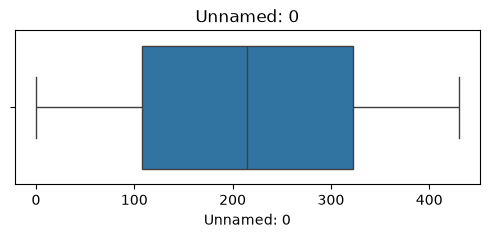

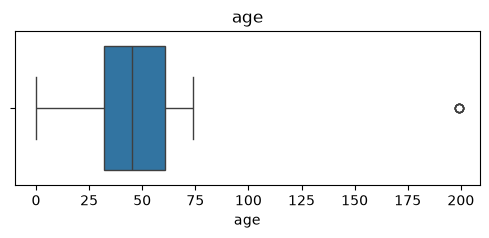

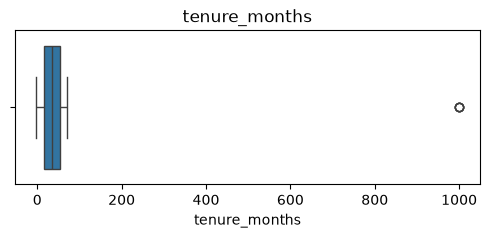

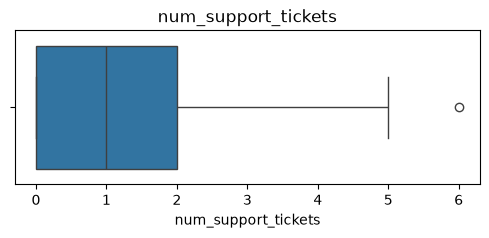

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

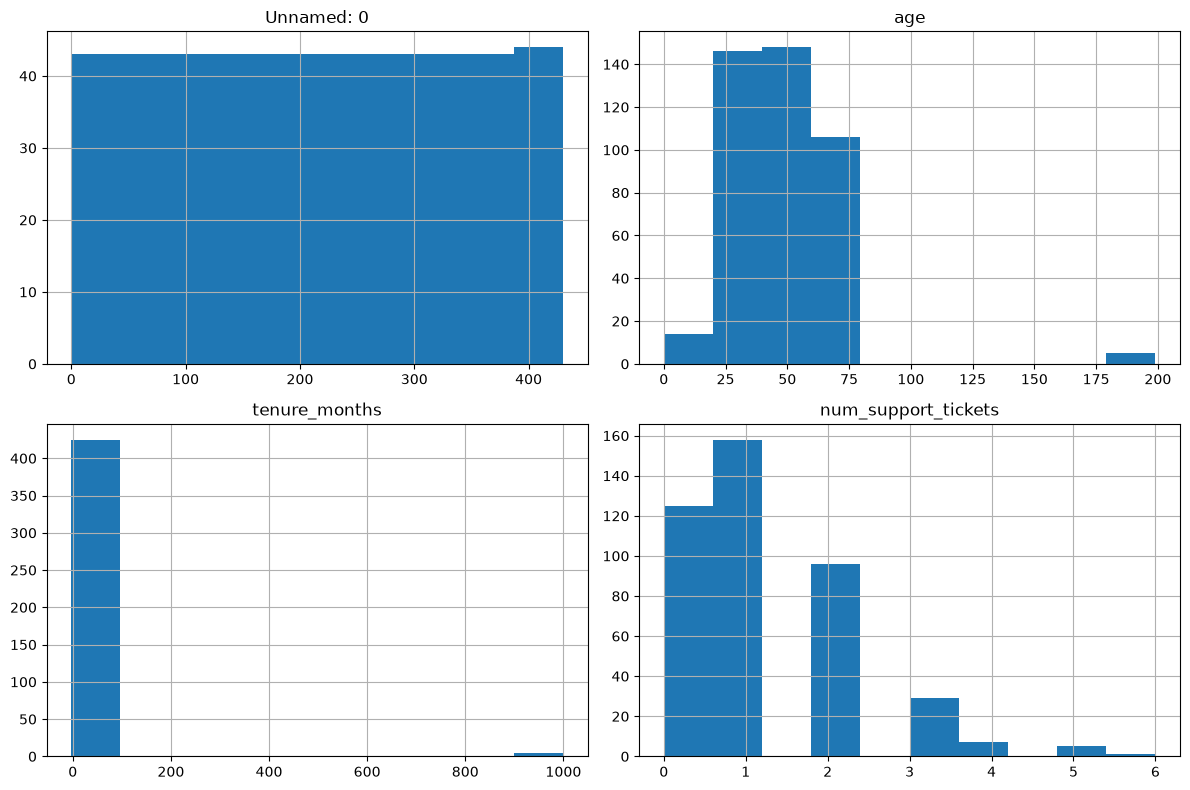

In [13]:
df.hist(figsize=(12,8))
plt.tight_layout()

In [15]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 60)
    print(f"Column: {col}")
    print(f"Unique Values: {df[col].nunique(dropna=False)}")
    print(df[col].value_counts(dropna=False))
    print()

Column: customer_id
Unique Values: 421
customer_id
CUST00214    2
CUST00335    2
CUST00379    2
CUST00166    2
NaN          2
            ..
CUST00212    1
CUST00068    1
CUST00026    1
CUST00197    1
CUST00176    1
Name: count, Length: 421, dtype: int64

Column: gender
Unique Values: 12
gender
F           49
male        44
Male        41
FEMALE      41
female      41
 Female     39
Female      38
 Male       38
MALE        35
M           28
NaN         24
Unknown     13
Name: count, dtype: int64

Column: contract_type
Unique Values: 13
contract_type
Month-to-month      145
One year             62
Two year             51
month-to-month       50
MONTH-TO-MONTH       34
two year             18
ONE YEAR             18
TWO YEAR             13
 Month-to-month      12
 One year             9
one year              9
 Two year             8
NaN                   2
Name: count, dtype: int64

Column: payment_method
Unique Values: 5
payment_method
Mailed check        122
Credit card         111
B

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11856\1908566174.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [16]:
print(df.dtypes)

Unnamed: 0               int64
customer_id                str
age                    float64
gender                     str
tenure_months          float64
contract_type              str
payment_method             str
monthly_charges            str
total_charges              str
num_support_tickets    float64
signup_date                str
has_churned                str
dtype: object


In [17]:
df["monthly_charges"].head(20)

0     $59.74
1     112.67
2        NaN
3     $87.66
4      54.93
5      58.99
6     120.52
7     $29.78
8       49.6
9      48.45
10    $69.94
11     104.8
12    $51.38
13    105.25
14     65.63
15    $54.65
16      67.8
17     133.3
18    $81.75
19      84.6
Name: monthly_charges, dtype: str

In [18]:
df["total_charges"].head(20)

0       4178.01
1     $5,319.53
2           0.0
3       3832.18
4           NaN
5           NaN
6        1688.4
7     $1,665.94
8        782.19
9       3441.05
10      3903.04
11      2950.81
12       421.57
13          NaN
14          NaN
15    $1,366.32
16        87.85
17      2125.35
18    $2,847.21
19      1784.88
Name: total_charges, dtype: str

In [19]:
df["signup_date"].head(20)

0      2019-09-17
1      2022-03-13
2      2021-11-24
3      10/25/2022
4      2022-05-24
5      2020-07-10
6      2022-04-28
7      09/27/2022
8             NaN
9     26-Jun-2019
10    12-Nov-2023
11    27-Feb-2020
12     12/26/2019
13     2019-10-31
14     2020-04-04
15     2021-02-27
16            NaN
17            NaN
18     2019-08-14
19     02/13/2019
Name: signup_date, dtype: str

In [20]:
duplicate_customers = df[df["customer_id"].duplicated(keep=False)]
duplicate_customers.sort_values("customer_id")

,Unnamed: 0,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned
163,163,CUST00005,42.0,female,17.0,Month-to-month,Credit card,96.24,1627.28,2.0,07/15/2019,0
363,363,CUST00005,42.0,female,17.0,Month-to-month,Credit card,96.24,1627.28,2.0,07/15/2019,0
358,358,CUST00018,25.0,Female,55.0,Two year,Bank transfer,$85.54,NaN,3.0,23-Aug-2022,No
302,302,CUST00018,25.0,Female,55.0,Two year,Bank transfer,$85.54,NaN,3.0,23-Aug-2022,No
73,73,CUST00166,64.0,MALE,58.0,MONTH-TO-MONTH,Bank transfer,$100.80,5853.29,0.0,NaN,0
286,286,CUST00166,64.0,MALE,58.0,MONTH-TO-MONTH,Bank transfer,$100.80,5853.29,0.0,NaN,0
118,118,CUST00180,46.0,NaN,68.0,Month-to-month,Credit card,90.12,6116.88,5.0,10/09/2023,N
250,250,CUST00180,46.0,NaN,68.0,Month-to-month,Credit card,90.12,6116.88,5.0,10/09/2023,N
6,6,CUST00214,43.0,male,14.0,month-to-month,Credit card,120.52,1688.4,0.0,2022-04-28,1
200,200,CUST00214,43.0,male,14.0,month-to-month,Credit card,120.52,1688.4,0.0,2022-04-28,1


In [21]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [23]:
df.columns

Index(['customer_id', 'age', 'gender', 'tenure_months', 'contract_type',
       'payment_method', 'monthly_charges', 'total_charges',
       'num_support_tickets', 'signup_date', 'has_churned'],
      dtype='str')

In [24]:
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].astype(str).str.strip()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11856\2102953851.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns


In [25]:
for col in object_cols:
    print(col)
    print(df[col].head())

customer_id
0    CUST00121
1    CUST00178
2    CUST00222
3    CUST00378
4    CUST00279
Name: customer_id, dtype: str
gender
0         F
1    Female
2    Female
3      Male
4    Female
Name: gender, dtype: str
contract_type
0    Month-to-month
1          two year
2          One year
3          One year
4    Month-to-month
Name: contract_type, dtype: str
payment_method
0         Credit card
1       Bank transfer
2         Credit card
3    Electronic check
4    Electronic check
Name: payment_method, dtype: str
monthly_charges
0    $59.74
1    112.67
2       NaN
3    $87.66
4     54.93
Name: monthly_charges, dtype: str
total_charges
0      4178.01
1    $5,319.53
2          0.0
3      3832.18
4          NaN
Name: total_charges, dtype: str
signup_date
0    2019-09-17
1    2022-03-13
2    2021-11-24
3    10/25/2022
4    2022-05-24
Name: signup_date, dtype: str
has_churned
0    false
1      Yes
2     true
3     true
4       No
Name: has_churned, dtype: str


In [26]:
categorical_cols = [
    "gender",
    "contract_type",
    "payment_method",
    "has_churned"
]

for col in categorical_cols:
    df[col] = df[col].str.lower()

In [27]:
for col in categorical_cols:
    print("="*40)
    print(col)
    print(df[col].value_counts(dropna=False))

gender
gender
female     159
male       158
f           49
m           28
NaN         24
unknown     13
Name: count, dtype: int64
contract_type
contract_type
month-to-month    241
one year           98
two year           90
NaN                 2
Name: count, dtype: int64
payment_method
payment_method
mailed check        122
credit card         111
bank transfer       103
electronic check     93
NaN                   2
Name: count, dtype: int64
has_churned
has_churned
no       83
0        79
false    74
n        74
y        34
true     31
yes      28
1        26
NaN       2
Name: count, dtype: int64


In [28]:
df["monthly_charges"].sample(15)

154      78.5
282    $75.29
165    102.16
290    107.25
408     56.61
241     46.46
0      $59.74
402    $87.06
143     64.04
68      68.13
48      64.66
308     78.97
367    $38.01
267    $23.58
382     77.56
Name: monthly_charges, dtype: str

In [29]:
df["total_charges"].sample(15)

158       556.82
422        68.33
46        394.39
27     $1,057.99
261    $5,249.69
95        161.02
381          NaN
45        750.58
299        47.12
305    $1,515.97
84       2322.47
268    $4,325.08
421          NaN
165       823.73
81        3011.0
Name: total_charges, dtype: str

In [ ]:
df["monthly_charges"].sample(15)

167     103.2
78      73.75
138     72.56
162      44.2
46      47.81
417     91.43
325     58.47
400    111.01
134     58.85
65      60.71
207     71.69
430     62.32
251    108.04
266    $95.96
263    $31.68
Name: monthly_charges, dtype: str

In [31]:
df["total_charges"].sample(15)

236       181.38
34     $3,999.22
391    $2,576.03
90        766.08
106      $156.87
260      5648.95
337      2840.22
189       950.78
219       995.31
278      4098.52
3        3832.18
240      4958.26
207       210.84
227      1084.78
404        69.35
Name: total_charges, dtype: str

In [32]:
df["monthly_charges"] = (
    df["monthly_charges"]
      .str.replace("$", "", regex=False)
)

df["monthly_charges"] = pd.to_numeric(
    df["monthly_charges"],
    errors="coerce"
)

In [33]:
df["monthly_charges"].dtype

dtype('float64')

In [34]:
df["total_charges"] = (
    df["total_charges"]
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
)

df["total_charges"] = pd.to_numeric(
    df["total_charges"],
    errors="coerce"
)

In [35]:
df["total_charges"].dtype

dtype('float64')

In [36]:
df.isnull().sum()

customer_id             2
age                    12
gender                 24
tenure_months           2
contract_type           2
payment_method          2
monthly_charges        26
total_charges          40
num_support_tickets    10
signup_date            26
has_churned             2
dtype: int64

In [37]:
df["signup_date"].sample(20)

216     04/26/2019
289            NaN
276     2020-01-26
221     2021-02-15
102     11/12/2019
421     2022-10-16
5       2020-07-10
239    15-Apr-2022
170     03/17/2020
147     2020-07-19
241     10/10/2021
209    16-Jul-2022
278     2022-09-03
280     07/02/2023
157     08/01/2019
105            NaN
381    19-Jan-2023
127    17-Sep-2022
409     2022-10-11
217     02/17/2023
Name: signup_date, dtype: str

In [38]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    format="mixed",
    errors="coerce"
)

In [39]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    errors="coerce"
)

In [42]:
df["signup_date"].head()


0   2019-09-17
1   2022-03-13
2   2021-11-24
3   2022-10-25
4   2022-05-24
Name: signup_date, dtype: datetime64[us]

In [43]:
df["signup_date"].dtype

dtype('<M8[us]')

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          429 non-null    str           
 1   age                  419 non-null    float64       
 2   gender               407 non-null    str           
 3   tenure_months        429 non-null    float64       
 4   contract_type        429 non-null    str           
 5   payment_method       429 non-null    str           
 6   monthly_charges      405 non-null    float64       
 7   total_charges        391 non-null    float64       
 8   num_support_tickets  421 non-null    float64       
 9   signup_date          405 non-null    datetime64[us]
 10  has_churned          429 non-null    str           
dtypes: datetime64[us](1), float64(5), str(5)
memory usage: 37.2 KB


In [45]:
df.isnull().sum()

customer_id             2
age                    12
gender                 24
tenure_months           2
contract_type           2
payment_method          2
monthly_charges        26
total_charges          40
num_support_tickets    10
signup_date            26
has_churned             2
dtype: int64

In [46]:
df["age"] = df["age"].fillna(df["age"].median())

In [47]:
df["tenure_months"] = df["tenure_months"].fillna(df["tenure_months"].median())

In [48]:
df["num_support_tickets"] = df["num_support_tickets"].fillna(
    df["num_support_tickets"].median()
)

In [49]:
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

In [51]:
df["contract_type"] = df["contract_type"].fillna(
    df["contract_type"].mode()[0]
)

In [52]:
df["payment_method"] = df["payment_method"].fillna(
    df["payment_method"].mode()[0]
)

In [53]:
df["monthly_charges"] = df["monthly_charges"].fillna(
    df["monthly_charges"].median()
)

In [54]:
df["total_charges"] = df["total_charges"].fillna(
    df["total_charges"].median()
)

In [55]:
median_date = df["signup_date"].dropna().sort_values().iloc[len(df["signup_date"].dropna())//2]

df["signup_date"] = df["signup_date"].fillna(median_date)

In [56]:
mask = df["customer_id"].isna()

df.loc[mask, "customer_id"] = [
    f"UNKNOWN_{i}" for i in range(mask.sum())
]

In [57]:
df = df.dropna(subset=["has_churned"])

In [58]:
df.isnull().sum()

customer_id            0
age                    0
gender                 0
tenure_months          0
contract_type          0
payment_method         0
monthly_charges        0
total_charges          0
num_support_tickets    0
signup_date            0
has_churned            0
dtype: int64

In [60]:
import numpy as np

In [61]:
df.loc[(df["age"] < 18) | (df["age"] > 100), "age"] = np.nan

df["age"] = df["age"].fillna(df["age"].median())

In [63]:
df.loc[
    (df["tenure_months"] < 0) |
    (df["tenure_months"] > 120),
    "tenure_months"
] = np.nan

df["tenure_months"] = df["tenure_months"].fillna(
    df["tenure_months"].median()
)

In [64]:
df.describe()

,age,tenure_months,monthly_charges,total_charges,num_support_tickets,signup_date
count,429.000000,429.000000,429.000000,429.000000,429.000000,429
mean,45.554779,34.590909,70.599394,2380.607925,1.174825,2021-06-07 18:57:54.125874
min,18.000000,0.000000,15.000000,0.000000,0.000000,2019-01-02 00:00:00
25%,33.000000,17.000000,55.350000,1082.140000,0.000000,2020-04-04 00:00:00
50%,45.000000,34.500000,69.500000,2125.990000,1.000000,2021-06-08 00:00:00
75%,59.000000,53.000000,87.280000,3302.410000,2.000000,2022-07-13 00:00:00
max,74.000000,71.000000,139.190000,8917.310000,6.000000,2023-12-04 00:00:00
std,15.816113,21.006032,24.324267,1629.334283,1.072041,NaN


In [65]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 9


In [66]:
df = df.drop_duplicates()

In [67]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [68]:
duplicates = df[df["customer_id"].duplicated(keep=False)]
duplicates.sort_values("customer_id")

,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned


In [69]:
df = df.drop_duplicates(subset="customer_id", keep="first")

In [71]:
# this is Feature Engineering part
# Feature 1 – Average Charge Per Month
df["avg_charge_per_month"] = (
    df["total_charges"] / df["tenure_months"].replace(0, 1)
)

In [72]:
# Feature 2 – Tenure Group
df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0,12,24,48,120],
    labels=["New","1-2 Years","2-4 Years","4+ Years"]
)

In [73]:
# Feature 3 – High Support Ticket Flag
df["high_support"] = (
    df["num_support_tickets"] >= 3
).astype(int)

In [74]:
# Feature 4 – Senior Citizen
df["is_senior"] = (
    df["age"] >= 60
).astype(int)

In [77]:
df.to_csv("clean_customer_churn.csv", index=False)


In [78]:
import os

os.makedirs("output", exist_ok=True)
df.to_csv("output/clean_customer_churn.csv", index=False)


In [79]:
import os

print(os.getcwd())

d:\day2_data_preprocessing
